In [16]:
import sys
sys.path.append("../src")

from preprocessing import run_preprocessing_pipeline
from funnel import build_funnel, conversion_by_segment, first_purchase_distribution
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  
plt.rcParams['axes.unicode_minus'] = False

In [17]:
df = run_preprocessing_pipeline(config_path="../config/config.yaml")
df.head()

[INFO] 로드 완료: 3024행 x 13열
[INFO] 전처리 완료. 저장 경로: ../data/processed/processed_data.csv


,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate,HasPurchased,is_whale,session_bin,age_group
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19,1,0,6-10,45-54
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08,1,0,11-20,13-17
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02,1,0,6-10,18-24
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01,1,0,11-20,25-34
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05,1,0,6-10,35-44


In [18]:
funnel = build_funnel(df, engaged_threshold_minutes=20)
funnel

,stage,users,pct_of_install,step_conversion
0,Install,3024,100.0,NaN
1,Active,3024,100.0,100.0
2,Engaged,1540,50.9,50.9
3,Purchase,2888,95.5,187.5


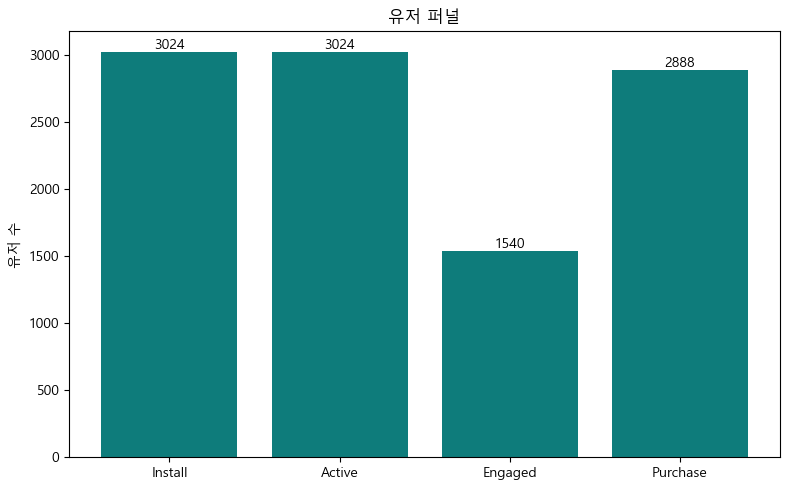

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(funnel["stage"], funnel["users"], color="#0E7C7B")
plt.title("유저 퍼널")
plt.ylabel("유저 수")
for i, v in enumerate(funnel["users"]):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [20]:
genre_summary = conversion_by_segment(df, "GameGenre")
genre_summary

,total,purchasers,revenue,cvr_pct,arpu
GameGenre,,,,,
Sports,217,210,16167.90,96.8,74.5
Casual,209,202,15783.34,96.7,75.5
Card,202,195,16392.15,96.5,81.1
Action RPG,191,184,11587.56,96.3,60.7
Simulation,219,210,17804.21,95.9,81.3
MOBA,181,173,24190.19,95.6,133.6
Strategy,198,189,27066.62,95.5,136.7
Adventure,170,162,15712.46,95.3,92.4
Racing,191,182,29163.56,95.3,152.7


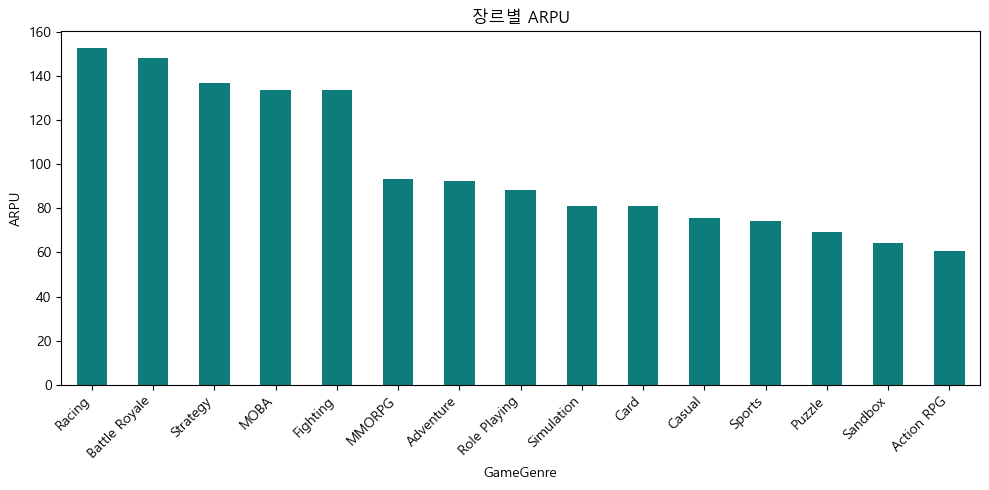

In [22]:
plt.figure(figsize=(10, 5))
genre_summary.sort_values("arpu", ascending=False)["arpu"].plot(kind="bar", 
                                                                color="#0E7C7B")
plt.title("장르별 ARPU")
plt.ylabel("ARPU")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
first_purchase = first_purchase_distribution(df)
print(f"평균: {first_purchase['mean_days']}일")
print(f"중앙값: {first_purchase['median_days']}일")
first_purchase["distribution"]

평균: 15.4일
중앙값: 16.0일


FirstPurchaseDaysAfterInstall
당일          83
1-3일       291
4-7일       330
8-14일      614
15-30일    1570
Name: count, dtype: int64

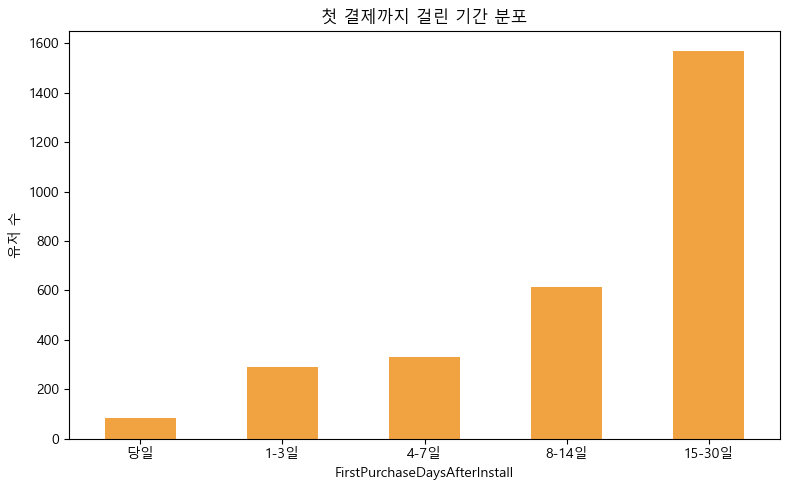

In [24]:
first_purchase["distribution"].plot(kind="bar", color="#F2A341", figsize=(8, 5))
plt.title("첫 결제까지 걸린 기간 분포")
plt.ylabel("유저 수")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()